<Axes: >

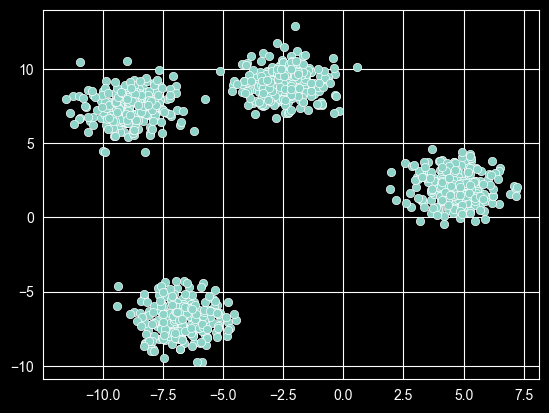

In [1]:
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

X, y = make_blobs(n_samples=1000, n_features=2, centers=4, random_state=42)

# Visualize

sns.scatterplot(x=X[:, 0], y=X[:, 1])


<Axes: >

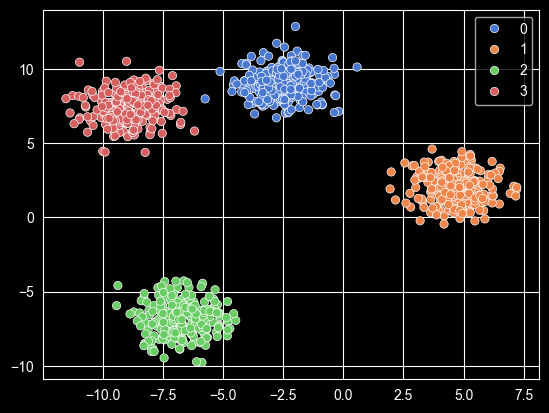

In [2]:
# K-Means Clustering
from sklearn.cluster import KMeans, dbscan

K = 4

kmeans = KMeans(n_clusters=K, random_state=42)

labels = kmeans.fit_predict(X) # labels are for cluster numbers

sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="muted")

<Axes: >

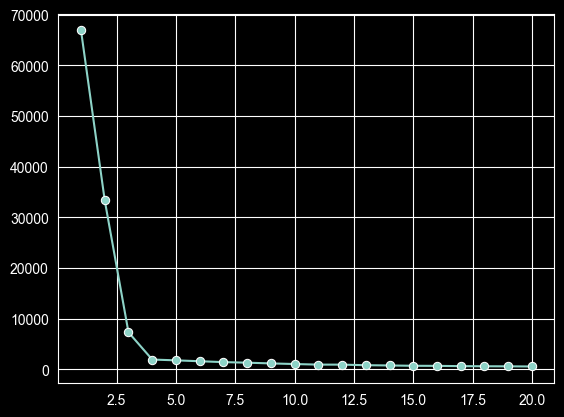

In [3]:
## How to Choose our K value - elbow; silhouette score

# Elbow Method

wcss = []

for k in range(1, 21):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)

sns.lineplot(x=range(1, 21), y=wcss, marker='o')

In [4]:
# Kneed Module
from kneed import KneeLocator

knee = KneeLocator(range(1,21), wcss, curve="convex", direction="decreasing")

print("optimal K = ",knee.elbow)

optimal K =  4


<Axes: >

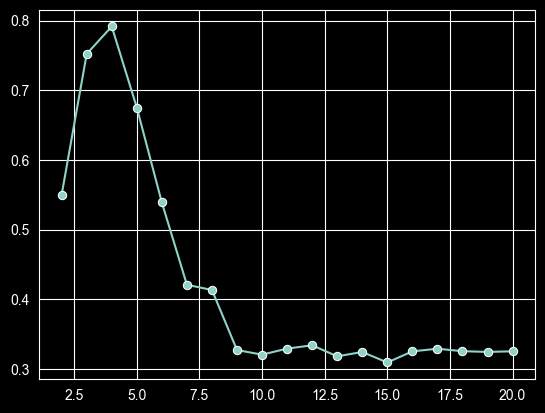

In [5]:
# Silhouette Score
from sklearn.metrics import silhouette_score

ss = []

for k in range(2, 21):
    kmeans = KMeans(n_clusters=k)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    ss.append(score)


# plot - K & ss

sns.lineplot(x=range(2, 21), y=ss, marker='o')

In [6]:
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
iris = load_iris()

X = iris.data
y = iris.target


<Axes: >

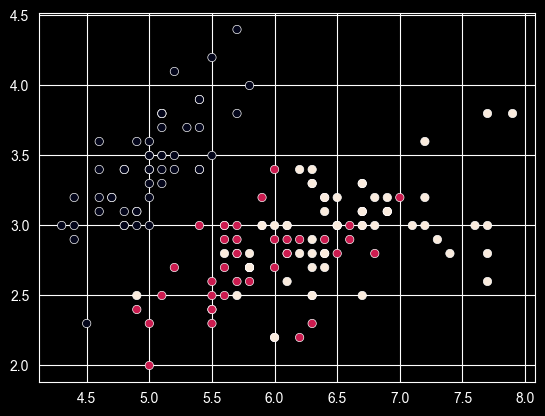

In [7]:
# Visualize

sns.scatterplot(x=X[:, 0], y=X[:, 1], c=y)

<Axes: >

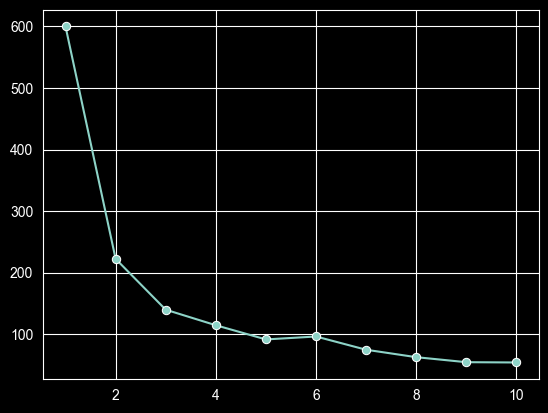

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Elbow method

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

sns.lineplot(x=range(1, 11), y=wcss, marker='o')

<Axes: >

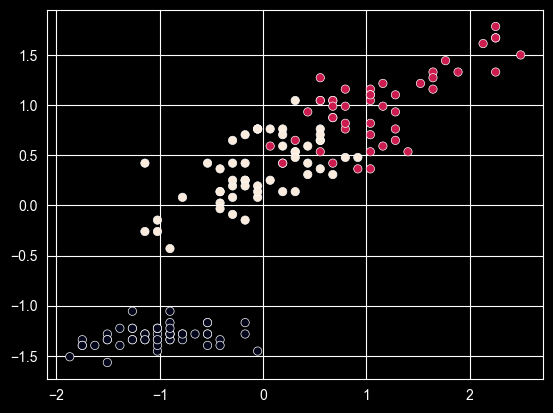

In [9]:
# KMeans

kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(X_scaled)

sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 2], c=labels)

In [10]:
# optional - dimensionality reduction using PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(X)

<Axes: >

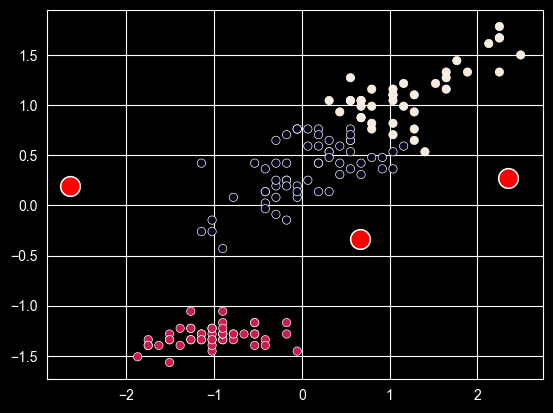

In [11]:
# KMeans

kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(pca_data)

sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 2], c=labels)
sns.scatterplot(x=kmeans.cluster_centers_[:,0], y=kmeans.cluster_centers_[:,1], marker='o',c="red", s=200)

<Axes: >

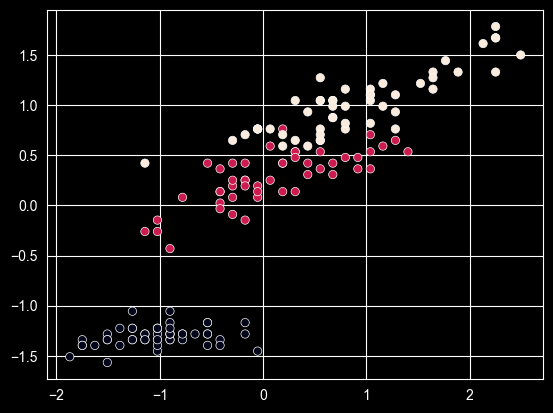

In [12]:
# hierarchical clustering

from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


iris = load_iris()
X = iris.data
y = iris.target

#Scale

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# visualize

sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 2], c=y)

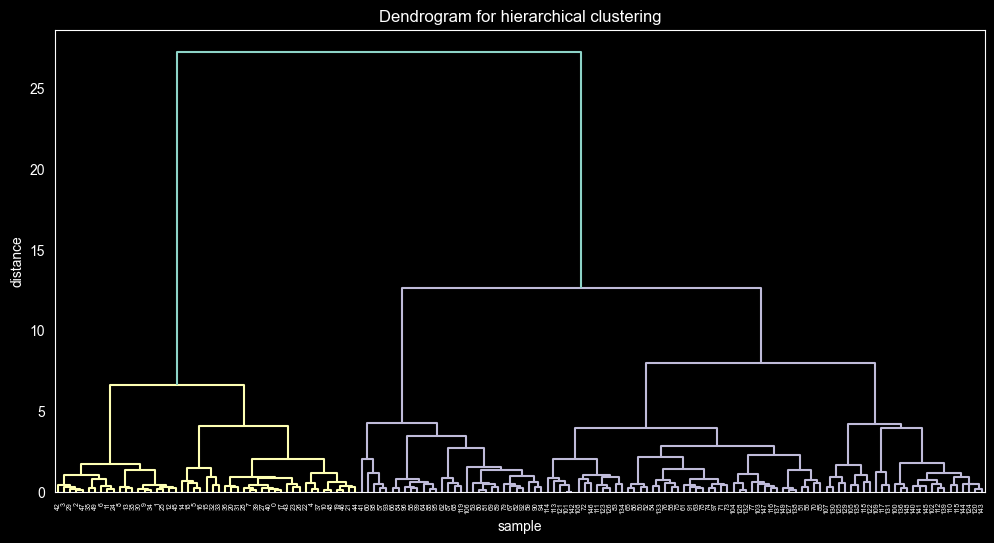

In [13]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Linkage matrix

Z = linkage(X_scaled, method='ward')

# Plot

plt.figure(figsize=(12,6))
dendrogram(Z)
plt.xlabel("sample")
plt.ylabel("distance")
plt.title("Dendrogram for hierarchical clustering")
plt.grid(False)
plt.show()

<Axes: >

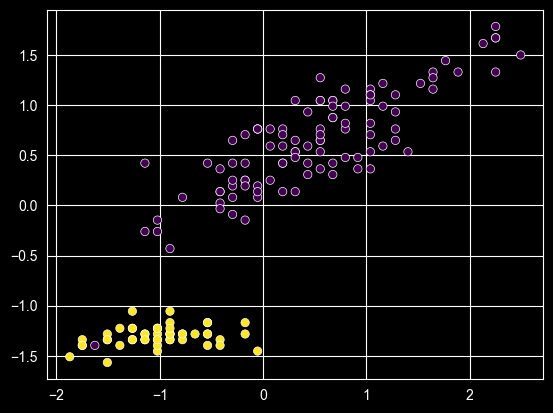

In [14]:
# Clustering

from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=2)
labels = agg.fit_predict(X_scaled)

sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 2], c=labels, cmap="viridis")

<Axes: >

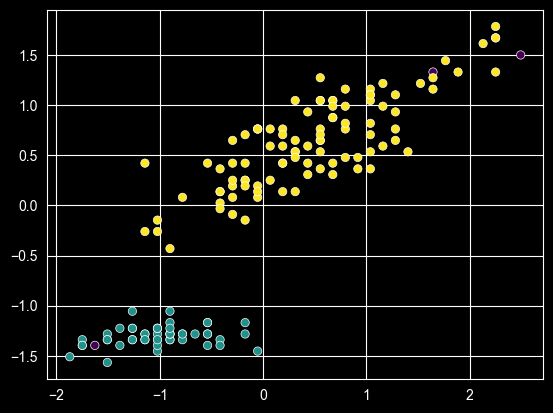

In [15]:
# DBSCAN Clustering
from sklearn.cluster import DBSCAN
from sklearn.datasets import load_iris
import seaborn as sns
from sklearn.preprocessing import StandardScaler


iris = load_iris()
X = iris.data
y = iris.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

dbscan = DBSCAN(eps=0.8, min_samples=5)

labels = dbscan.fit_predict(X_scaled)

sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 2], c=labels, cmap="viridis")




<Axes: >

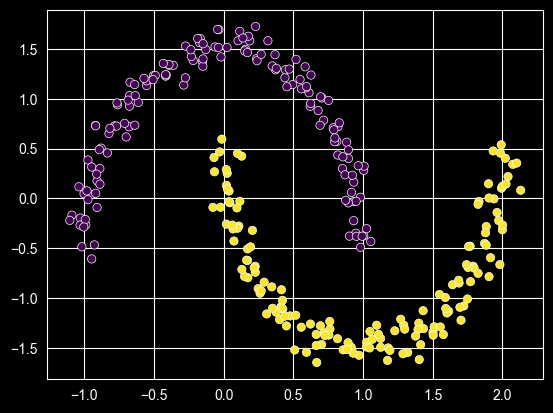

In [16]:
## DBSCAN on non-linear algorithm

from sklearn.datasets import make_moons

X, y = make_moons(n_samples=300,noise=0.05 ,random_state=42)

X_scaled = scaler.fit_transform(X)

sns.scatterplot(x=X[:, 0], y=X_scaled[:, 1], c=y, cmap="viridis")

<Axes: >

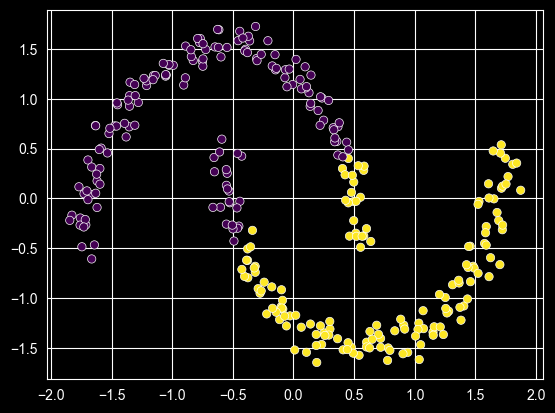

In [17]:
# K-means

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X_scaled)

sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], c=labels, cmap="viridis")

<Axes: >

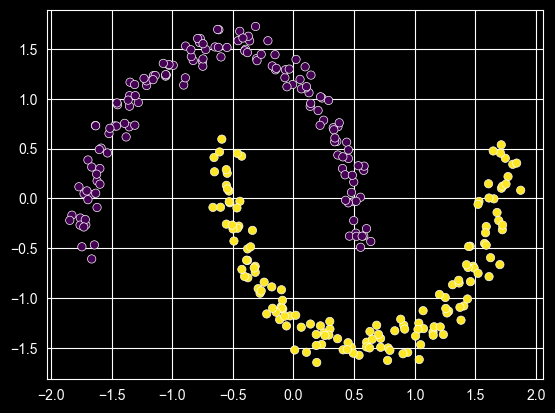

In [18]:
# DBSCAN

dbscan = DBSCAN(eps=0.8, min_samples=5)

labels = dbscan.fit_predict(X_scaled)

sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], c=y, cmap="viridis")

In [19]:
# PCA

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from  sklearn.preprocessing import StandardScaler

iris = load_iris()

X = pd.DataFrame(iris.data)
y = pd.DataFrame(iris.target)

X.head()

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA om this data

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print()
print(pca.components_)

Explained Variance Ratio: [0.72962445 0.22850762]

[[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]]


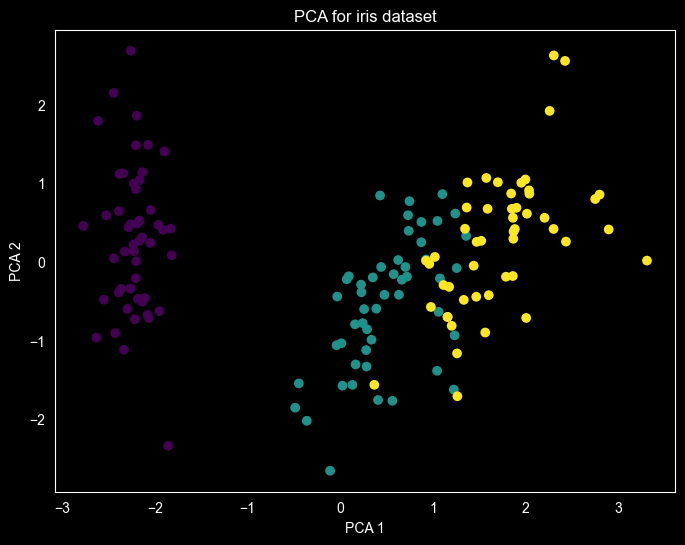

In [21]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="viridis")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA for iris dataset")
plt.grid(False)
plt.show()

<Axes: >

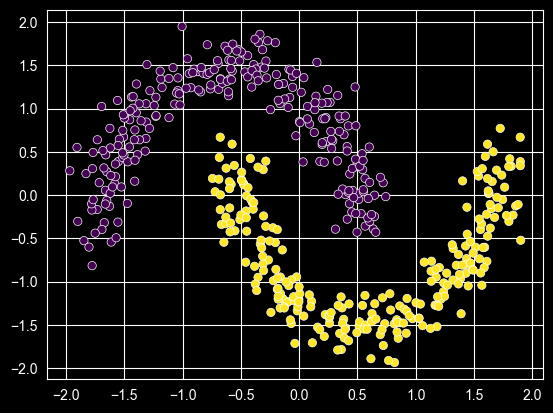

In [22]:
#DBSCAN
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

X,y = make_moons(n_samples=500,noise=0.1,random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#visualzie
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], c=y, cmap="viridis")

<Axes: >

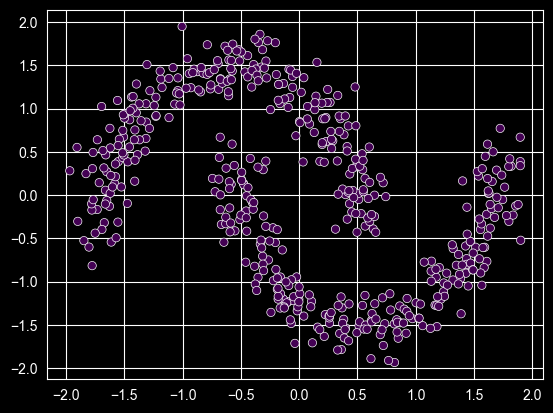

In [23]:
dbscan = DBSCAN(
    eps=0.8,
    min_samples=5,
)

labels = dbscan.fit_predict(X_scaled)

sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], c=labels, cmap="viridis")